# Logistic Regression

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option('display.precision', 3)
np.set_printoptions(precision=3)

from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import seaborn as sns
sns.set()


import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

In [2]:
# データの読み込み
df = pd.read_csv('../data/adult.csv')

# 2値分類の目的変数の作成
df["income_binary"] = (df["income"] == ">50K").astype(int)

# 不要列削除
df = df.drop(columns=['fnlwgt', 'education', 'income'])

# 列名のドットをアンダーバーに置換
df.columns = df.columns.str.replace('.', '_', regex=False)

In [3]:
# train_test分割
train_df, test_df = train_test_split(df, test_size=0.2, random_state=123)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [4]:
# 全foldでカテゴリを固定（クロスバリデーションのエラー対策）
cat_cols = [
    'workclass','occupation','marital_status',
    'relationship','race','sex','native_country'
]

for col in cat_cols:
    train_df[col] = train_df[col].astype('category')
    # train_dfのカテゴリ定義を用いてtest_dfをカテゴリ型に変換
    test_df[col] = pd.Categorical(
        test_df[col], 
        categories=train_df[col].cat.categories
    )

## バリデーション設計（確認用）

### ホールドアウト検証

In [5]:
train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)
print(train_tr.shape, train_va.shape)
print('train_df : {}, train_tr : {}, train_va : {}'.format(
    train_df['income_binary'].mean(), train_tr['income_binary'].mean(), train_va['income_binary'].mean())
)

(20838, 13) (5210, 13)
train_df : 0.23948095823095822, train_tr : 0.2386025530281217, train_va : 0.24299424184261037


### クロスバリデーション

In [6]:
n_splits = 5
cv = list(StratifiedKFold(
    n_splits=n_splits, 
    shuffle=True, 
    random_state=123
).split(train_df, train_df['income_binary']))

for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    print(train_fold.shape, valid_fold.shape)
    print('train_df : {}, train_fold : {}, valid_fold : {}'.format(
        train_df['income_binary'].mean(), train_fold['income_binary'].mean(), valid_fold['income_binary'].mean()
    ))

-------------------- 0 --------------------
(20838, 13) (5210, 13)
train_df : 0.23948095823095822, train_fold : 0.23946635953546405, valid_fold : 0.23953934740882918
-------------------- 1 --------------------
(20838, 13) (5210, 13)
train_df : 0.23948095823095822, train_fold : 0.23946635953546405, valid_fold : 0.23953934740882918
-------------------- 2 --------------------
(20838, 13) (5210, 13)
train_df : 0.23948095823095822, train_fold : 0.23946635953546405, valid_fold : 0.23953934740882918
-------------------- 3 --------------------
(20839, 13) (5209, 13)
train_df : 0.23948095823095822, train_fold : 0.23950285522337925, valid_fold : 0.23939335765022077
-------------------- 4 --------------------
(20839, 13) (5209, 13)
train_df : 0.23948095823095822, train_fold : 0.23950285522337925, valid_fold : 0.23939335765022077


## 特徴量エンジニアリング前

## モデル学習（ベースライン・ageのみ）

### ホールドアウト検証の場合

In [7]:
train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model = smf.glm(
    formula='income_binary ~ age', 
    data=train_tr, 
    family=sm.families.Binomial()
).fit()

y_true = train_va['income_binary']
y_pred = model.predict(train_va)
y_pred_label = (y_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_true, y_pred_label)
auc = roc_auc_score(y_true, y_pred)

print(f'Accuracy: {accuracy:.3f}')
print(f'ROC-AUC: {auc:.3f}')

Accuracy: 0.746
ROC-AUC: 0.680


### クロスバリデーションの場合

In [8]:
n_splits = 5
cv = list(StratifiedKFold(
    n_splits=n_splits, 
    shuffle=True, 
    random_state=123
).split(train_df, train_df['income_binary']))
scores = []

for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model = smf.glm(
        formula='income_binary ~ age', 
        data=train_fold, 
        family=sm.families.Binomial()
    ).fit()
    
    y_true = valid_fold['income_binary']
    y_pred = model.predict(valid_fold)
    y_pred_label = (y_pred >= 0.5).astype(int)
    
    accuracy = accuracy_score(y_true, y_pred_label)
    auc = roc_auc_score(y_true, y_pred)
    
    print(f'Accuracy: {accuracy:.3f}')
    print(f'ROC-AUC: {auc:.3f}')
    
    scores.append({'fold': nfold, 'Accuracy': accuracy, 'ROC-AUC': auc})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"Accuracy : {score_df['Accuracy'].mean():.3f} ± {score_df['Accuracy'].std():.3f}")
print(f"ROC-AUC  : {score_df['ROC-AUC'].mean():.3f} ± {score_df['ROC-AUC'].std():.3f}")

-------------------- 0 --------------------
Accuracy: 0.748
ROC-AUC: 0.681
-------------------- 1 --------------------
Accuracy: 0.746
ROC-AUC: 0.694
-------------------- 2 --------------------
Accuracy: 0.751
ROC-AUC: 0.678
-------------------- 3 --------------------
Accuracy: 0.749
ROC-AUC: 0.684
-------------------- 4 --------------------
Accuracy: 0.748
ROC-AUC: 0.682
------------------ total ------------------
   fold  Accuracy  ROC-AUC
0     0     0.748    0.681
1     1     0.746    0.694
2     2     0.751    0.678
3     3     0.749    0.684
4     4     0.748    0.682
CV Results
Accuracy : 0.748 ± 0.002
ROC-AUC  : 0.684 ± 0.006


In [9]:
# 評価
model_final = smf.glm(
    formula='income_binary ~ age', 
    data=train_df, 
    family=sm.families.Binomial()
).fit()

y_test = test_df['income_binary']
y_pred = model_final.predict(test_df)
y_pred_label = (y_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_label)
auc = roc_auc_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.3f}')
print(f'ROC-AUC: {auc:.3f}')

Accuracy: 0.741
ROC-AUC: 0.686


## モデル学習（ベースライン・全変数）

### ホールドアウト検証の場合

In [10]:
train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model = smf.glm(
    formula='income_binary ~ age + education_num + hours_per_week + capital_gain + capital_loss + \
    C(workclass) + C(occupation) + C(marital_status) + C(relationship) + C(race) + C(sex) + C(native_country)', 
    data=train_tr, 
    family=sm.families.Binomial()
).fit()

y_true = train_va['income_binary']
y_pred = model.predict(train_va)
y_pred_label = (y_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_true, y_pred_label)
auc = roc_auc_score(y_true, y_pred)

print(f'Accuracy: {accuracy:.3f}')
print(f'ROC-AUC: {auc:.3f}')

Accuracy: 0.850
ROC-AUC: 0.899


### クロスバリデーションの場合

In [11]:
n_splits = 5
cv = list(StratifiedKFold(
    n_splits=n_splits, 
    shuffle=True, 
    random_state=123
).split(train_df, train_df['income_binary']))
scores = []

for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model = smf.glm(
        formula='income_binary ~ age + education_num + hours_per_week + capital_gain + capital_loss + \
        C(workclass) + C(occupation) + C(marital_status) + C(relationship) + C(race) + C(sex) + C(native_country)', 
        data=train_fold, 
        family=sm.families.Binomial()
    ).fit()
    
    y_true = valid_fold['income_binary']
    y_pred = model.predict(valid_fold)
    y_pred_label = (y_pred >= 0.5).astype(int)
    
    accuracy = accuracy_score(y_true, y_pred_label)
    auc = roc_auc_score(y_true, y_pred)
    
    print(f'Accuracy: {accuracy:.3f}')
    print(f'ROC-AUC: {auc:.3f}')
    
    scores.append({'fold': nfold, 'Accuracy': accuracy, 'ROC-AUC': auc})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"Accuracy : {score_df['Accuracy'].mean():.3f} ± {score_df['Accuracy'].std():.3f}")
print(f"ROC-AUC  : {score_df['ROC-AUC'].mean():.3f} ± {score_df['ROC-AUC'].std():.3f}")

-------------------- 0 --------------------
Accuracy: 0.855
ROC-AUC: 0.909
-------------------- 1 --------------------
Accuracy: 0.855
ROC-AUC: 0.906
-------------------- 2 --------------------
Accuracy: 0.856
ROC-AUC: 0.905
-------------------- 3 --------------------
Accuracy: 0.847
ROC-AUC: 0.905
-------------------- 4 --------------------
Accuracy: 0.844
ROC-AUC: 0.896
------------------ total ------------------
   fold  Accuracy  ROC-AUC
0     0     0.855    0.909
1     1     0.855    0.906
2     2     0.856    0.905
3     3     0.847    0.905
4     4     0.844    0.896
CV Results
Accuracy : 0.851 ± 0.005
ROC-AUC  : 0.904 ± 0.005


## 特徴量エンジニアリング後

In [12]:
# データの読み込み
df = pd.read_csv('../data/adult.csv')

# 2値分類の目的変数の作成
df["income_binary"] = (df["income"] == ">50K").astype(int)

# 列名のドットをアンダーバーに置換
df.columns = df.columns.str.replace('.', '_', regex=False)

In [13]:
# 欠損値「?」をUnknownに置換
cols = ['workclass', 'occupation', 'native_country']
df[cols] = df[cols].replace('?', 'Unknown')

In [14]:
# 対数変換
df['capital_gain_log'] = np.log1p(df['capital_gain'])
df['capital_loss_log'] = np.log1p(df['capital_loss'])

In [15]:
# education_numからeducation_levelを作成
edu_map = {
    1:'Low', 2:'Low', 3:'Low', 4:'Low',
    5:'Low', 6:'Low', 7:'Low', 8:'Low',
    9:'Middle', 10:'Middle', 11:'Middle', 12:'Middle',
    13:'High', 14:'High', 15:'High', 16:'High'
}

df['education_level'] = df['education_num'].map(edu_map)

In [16]:
# hours_per_weekのビン分割
df['hours_bin'] = pd.cut(
    df['hours_per_week'],
    bins=[0,30,40,50,100],
    labels=['Part-time','Full-time','Overtime','Extreme']
)

In [17]:
# ageのビン分割
df['age_bin'] = pd.cut(
    df['age'],
    bins=[0,20,30,40,50,60,100],
    labels=['~19','20~29','30~39','40~49','50~59','60~'], 
    right=False
)

In [18]:
# 少数カテゴリの変換（オーバーフロー対策、固定置換）
# workclass
df['workclass'] = df['workclass'].replace({
    'Without-pay': 'Other', 
    'Never-worked': 'Other'
})

# marital_status
df['marital_status'] = df['marital_status'].replace({
    'Married-AF-spouse': 'Married-civ-spouse'
})

# occupation
df['occupation'] = df['occupation'].replace({
    'Armed-Forces': 'Other-service'
})

In [19]:
# train_test分割
train_df, test_df = train_test_split(df, test_size=0.2, random_state=123)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [20]:
# 標準化
scaler = StandardScaler()
train_df[['capital_gain_log', 'capital_loss_log']] = scaler.fit_transform(
    train_df[['capital_gain_log', 'capital_loss_log']]
)
test_df[['capital_gain_log', 'capital_loss_log']] = scaler.transform(
    test_df[['capital_gain_log', 'capital_loss_log']]
)

In [21]:
# 全foldでカテゴリを固定（クロスバリデーションのエラー対策）
cat_cols = [
    'workclass','occupation','marital_status',
    'relationship','race','sex','native_country', 
    'age_bin', 'hours_bin'
]
for col in cat_cols:
    train_df[col] = train_df[col].astype('category')
    # train_dfのカテゴリ定義を用いてtest_dfをカテゴリ型に変換
    test_df[col] = pd.Categorical(
        test_df[col], 
        categories=train_df[col].cat.categories
    )

In [22]:
# 少数カテゴリをOtherに変換（オーバーフロー対策、件数ベースの置換）
counts = train_df['native_country'].value_counts()
major_countries = counts[counts >= 50].index
    
train_df['native_country'] = np.where(
    train_df['native_country'].isin(major_countries), 
    train_df['native_country'], 
    'Other', 
)
    
test_df['native_country'] = np.where(
    test_df['native_country'].isin(major_countries), 
    test_df['native_country'], 
    'Other', 
)

In [23]:
train_df['education_level'].value_counts()

education_level
Middle    16172
High       6442
Low        3434
Name: count, dtype: int64

In [24]:
train_df.groupby('education_level')['income_binary'].mean().sort_values()

education_level
Low       0.060
Middle    0.181
High      0.482
Name: income_binary, dtype: float64

<Axes: xlabel='education_level'>

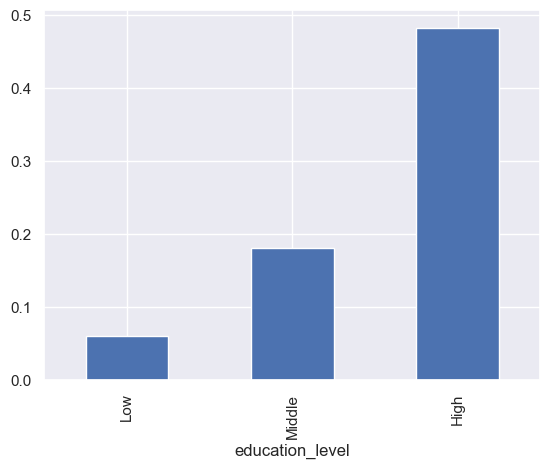

In [25]:
train_df.groupby('education_level')['income_binary'].mean().sort_values().plot(kind='bar')

In [26]:
train_df['hours_bin'].value_counts()

hours_bin
Full-time    14178
Overtime      4756
Part-time     4192
Extreme       2922
Name: count, dtype: int64

In [27]:
train_df.groupby('hours_bin')['income_binary'].mean().sort_values()

hours_bin
Part-time    0.067
Full-time    0.204
Overtime     0.392
Extreme      0.409
Name: income_binary, dtype: float64

<Axes: xlabel='hours_bin'>

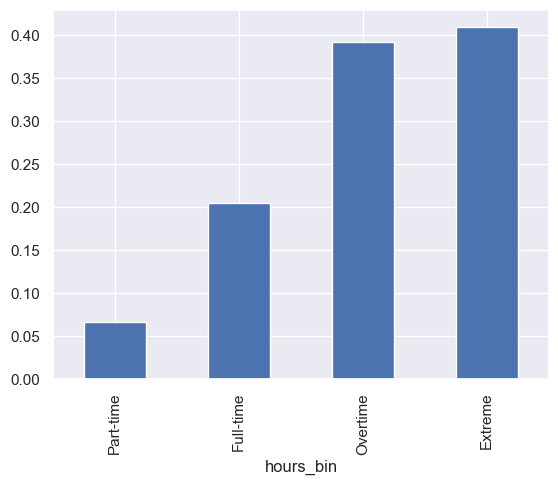

In [28]:
train_df.groupby('hours_bin')['income_binary'].mean().sort_values().plot(kind='bar')

In [29]:
train_df['age_bin'].value_counts()

age_bin
30~39    6882
20~29    6436
40~49    5745
50~59    3595
60~      2077
~19      1313
Name: count, dtype: int64

In [30]:
train_df.groupby('age_bin')['income_binary'].mean()

age_bin
~19      7.616e-04
20~29    6.168e-02
30~39    2.647e-01
40~49    3.744e-01
50~59    3.769e-01
60~      2.465e-01
Name: income_binary, dtype: float64

<Axes: xlabel='age_bin'>

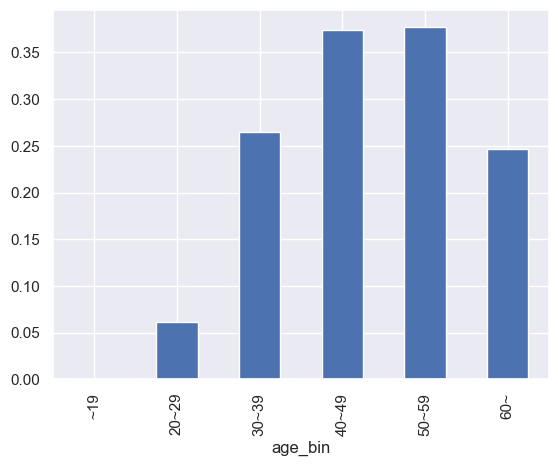

In [31]:
train_df.groupby('age_bin')['income_binary'].mean().plot(kind='bar')

## モデル学習

### ホールドアウト検証の場合

In [32]:
train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model = smf.glm(
    formula='income_binary ~ capital_gain_log + capital_loss_log + \
    C(age_bin, Treatment("20~29")) + \
    C(education_level, Treatment("Middle")) + \
    C(hours_bin, Treatment("Full-time")) + \
    C(workclass, Treatment("Private")) + \
    C(occupation, Treatment("Adm-clerical")) + \
    C(marital_status, Treatment("Married-civ-spouse")) + \
    C(relationship, Treatment("Husband")) + \
    C(race, Treatment("White")) + \
    C(sex, Treatment("Male")) + \
    C(native_country, Treatment("United-States"))', 
    data=train_tr, 
    family=sm.families.Binomial()
).fit()

y_true = train_va['income_binary']
y_pred = model.predict(train_va)
y_pred_label = (y_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_true, y_pred_label)
auc = roc_auc_score(y_true, y_pred)

print(f'Accuracy: {accuracy:.3f}')
print(f'ROC-AUC: {auc:.3f}')
print(f'AIC: {model.aic:.1f}')

Accuracy: 0.845
ROC-AUC: 0.898
AIC: 13541.8


### クロスバリデーションの場合

In [33]:
n_splits = 5
cv = list(StratifiedKFold(
    n_splits=n_splits, 
    shuffle=True, 
    random_state=123
).split(train_df, train_df['income_binary']))
scores = []

for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model = smf.glm(
        formula='income_binary ~ capital_gain_log + capital_loss_log + \
        C(age_bin, Treatment("20~29")) + \
        C(education_level, Treatment("Middle")) + \
        C(hours_bin, Treatment("Full-time")) + \
        C(workclass, Treatment("Private")) + \
        C(occupation, Treatment("Adm-clerical")) + \
        C(marital_status, Treatment("Married-civ-spouse")) + \
        C(relationship, Treatment("Husband")) + \
        C(race, Treatment("White")) + \
        C(sex, Treatment("Male")) + \
        C(native_country, Treatment("United-States"))', 
        data=train_fold, 
        family=sm.families.Binomial()
    ).fit()
    
    y_true = valid_fold['income_binary']
    y_pred = model.predict(valid_fold)
    y_pred_label = (y_pred >= 0.5).astype(int)
    
    accuracy = accuracy_score(y_true, y_pred_label)
    auc = roc_auc_score(y_true, y_pred)
    
    print(f'Accuracy: {accuracy: .3f}')
    print(f'ROC-AUC: {auc: .3f}')
    print(f'AIC: {model.aic:.1f}')
    
    scores.append({
        'fold': nfold, 
        'Accuracy': accuracy, 
        'ROC-AUC': auc, 
        'AIC': model.aic
    })
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"Accuracy : {score_df['Accuracy'].mean():.3f} ± {score_df['Accuracy'].std():.3f}")
print(f"ROC-AUC  : {score_df['ROC-AUC'].mean():.3f} ± {score_df['ROC-AUC'].std():.3f}")
print(f"AIC      : {score_df['AIC'].mean():.1f} ± {score_df['AIC'].std():.1f}")

-------------------- 0 --------------------
Accuracy:  0.849
ROC-AUC:  0.906
AIC: 13663.7
-------------------- 1 --------------------
Accuracy:  0.856
ROC-AUC:  0.906
AIC: 13688.1
-------------------- 2 --------------------
Accuracy:  0.848
ROC-AUC:  0.902
AIC: 13625.9
-------------------- 3 --------------------
Accuracy:  0.845
ROC-AUC:  0.900
AIC: 13606.5
-------------------- 4 --------------------
Accuracy:  0.840
ROC-AUC:  0.893
AIC: 13490.4
------------------ total ------------------
   fold  Accuracy  ROC-AUC        AIC
0     0     0.849    0.906  13663.661
1     1     0.856    0.906  13688.092
2     2     0.848    0.902  13625.928
3     3     0.845    0.900  13606.519
4     4     0.840    0.893  13490.357
CV Results
Accuracy : 0.848 ± 0.006
ROC-AUC  : 0.902 ± 0.005
AIC      : 13614.9 ± 76.5


## モデル推論

In [34]:
model_final = smf.glm(
    formula='income_binary ~ capital_gain_log + capital_loss_log + \
    C(age_bin, Treatment("20~29")) + \
    C(education_level, Treatment("Middle")) + \
    C(hours_bin, Treatment("Full-time")) + \
    C(workclass, Treatment("Private")) + \
    C(occupation, Treatment("Adm-clerical")) + \
    C(marital_status, Treatment("Married-civ-spouse")) + \
    C(relationship, Treatment("Husband")) + \
    C(race, Treatment("White")) + \
    C(sex, Treatment("Male")) + \
    C(native_country, Treatment("United-States"))', 
    data=train_df, 
    family=sm.families.Binomial()
).fit()

y_test = test_df['income_binary']
y_pred = model_final.predict(test_df)
y_pred_label = (y_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_label)
auc = roc_auc_score(y_test, y_pred)

print(f'Accuracy: {accuracy: .3f}')
print(f'ROC-AUC: {auc: .3f}')
print(f'AIC: {model_final.aic: .1f}')

Accuracy:  0.849
ROC-AUC:  0.906
AIC:  17003.4


In [35]:
model_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:          income_binary   No. Observations:                26048
Model:                            GLM   Df Residuals:                    25981
Model Family:                Binomial   Df Model:                           66
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8434.7
Date:                Fri, 15 May 2026   Deviance:                       16869.
Time:                        14:53:31   Pearson chi2:                 2.29e+04
No. Iterations:                    22   Pseudo R-squ. (CS):             0.3645
Covariance Type:            nonrobust                                         
===============================================================================================================================================
                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                      -1.8846      0.099    -19.017      0.000      -2.079      -1.690
C(age_bin, Treatment("20~29"))[T.~19]                                          -1.7343      1.009     -1.719      0.086      -3.712       0.243
C(age_bin, Treatment("20~29"))[T.30~39]                                         0.9368      0.071     13.228      0.000       0.798       1.076
C(age_bin, Treatment("20~29"))[T.40~49]                                         1.3913      0.073     19.172      0.000       1.249       1.534
C(age_bin, Treatment("20~29"))[T.50~59]                                         1.4746      0.078     18.880      0.000       1.322       1.628
C(age_bin, Treatment("20~29"))[T.60~]                                           1.0320      0.095     10.810      0.000       0.845       1.219
C(education_level, Treatment("Middle"))[T.High]                                 1.0458      0.049     21.262      0.000       0.949       1.142
C(education_level, Treatment("Middle"))[T.Low]                                 -0.9545      0.086    -11.117      0.000      -1.123      -0.786
C(hours_bin, Treatment("Full-time"))[T.Part-time]                              -0.8975      0.086    -10.478      0.000      -1.065      -0.730
C(hours_bin, Treatment("Full-time"))[T.Overtime]                                0.4945      0.048     10.221      0.000       0.400       0.589
C(hours_bin, Treatment("Full-time"))[T.Extreme]                                 0.4988      0.058      8.554      0.000       0.385       0.613
C(workclass, Treatment("Private"))[T.Federal-gov]                               0.4560      0.103      4.410      0.000       0.253       0.659
C(workclass, Treatment("Private"))[T.Local-gov]                                -0.3068      0.080     -3.833      0.000      -0.464      -0.150
C(workclass, Treatment("Private"))[T.Other]                                   -21.7686   2.15e+04     -0.001      0.999   -4.21e+04    4.21e+04
C(workclass, Treatment("Private"))[T.Self-emp-inc]                              0.2508      0.092      2.719      0.007       0.070       0.432
C(workclass, Treatment("Private"))[T.Self-emp-not-inc]                         -0.3625      0.069     -5.234      0.000      -0.498      -0.227
C(workclass, Treatment("Private"))[T.State-gov]                                -0.2454      0.100     -2.461      0.014      -0.441      -0.050
C(workclass, Treatment("Private"))[T.Unknown]                                  -4.5239   3.75e+04     -0.000      1.000   -7.34e+04    7.34e+04
C(occupation, Treatment("Adm-clerical"))[T.Craft-repair]   

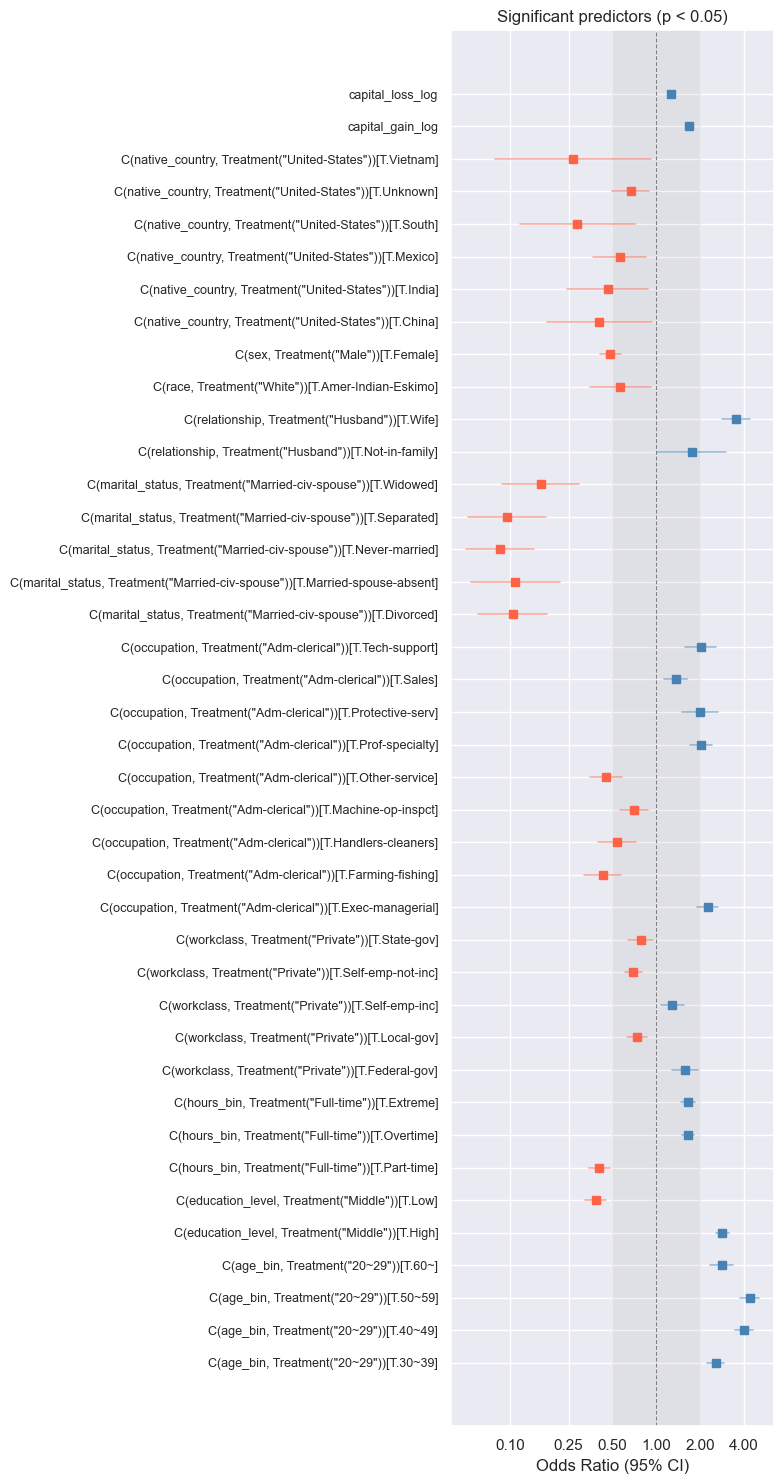

In [36]:
# ============================================================
# 図3：オッズ比
# ============================================================

# モデルから数値を取り出す
params = model_final.params    # 係数（対数オッズ比）
conf = model_final.conf_int()    # 信頼区間（対数オッズ比）
pvalues = model_final.pvalues    # p値

# 対数オッズ比からオッズ比に変換（クリップはオーバーフロー対策）
OR = np.exp(params)    # 対数オッズ比 → オッズ比
CI_lo = np.exp(np.clip(conf[0], -500, 500))   # 信頼区間の下限
CI_hi = np.exp(np.clip(conf[1], -500, 500))   # 信頼区間の上限

# p値 < 0.05 でフィルタリング
mask = pvalues < 0.05    # True/Falseのフラグを作る
OR_sig = OR[mask]    # Trueの行だけ残す
CI_lo_sig = CI_lo[mask]
CI_hi_sig = CI_hi[mask]

# Interceptは除外（解釈不要のため）
OR_sig = OR_sig.drop('Intercept', errors='ignore')
CI_lo_sig = CI_lo_sig.drop('Intercept', errors='ignore')
CI_hi_sig = CI_hi_sig.drop('Intercept', errors='ignore')

# Forest plot
fig, ax = plt.subplots(figsize=(8, len(OR_sig) * 0.35 + 1))    # 縦幅を変数の数に応じて自動調整

colors = ['steelblue' if v > 1 else 'tomato' for v in OR_sig]
y_pos = range(len(OR_sig))

# 0.5〜2.0をグレーで塗りつぶす（効果量が小さい範囲の目安）
ax.axvspan(0.5, 2.0, color='gray', alpha=0.1)
# OR=1.0の基準線
ax.axvline(x=1.0, color='gray', linewidth=0.8, linestyle='--')

for i, (name, or_val, lo, hi, c) in enumerate(zip(OR_sig.index, OR_sig, CI_lo_sig, CI_hi_sig, colors)):
    ax.plot([lo, hi], [i, i], color=c, linewidth=1.2, alpha=0.5)    # 信頼区間（横線）
    ax.plot(or_val, i, 's', color=c, markersize=6)    # オッズ比（■点） 's'はsquare（四角）のマーカー

# y軸ラベルの設定
ax.set_yticks(y_pos)    # 目盛りの位置：[0, 1, 2, ...]
ax.set_yticklabels(OR_sig.index, fontsize=9)    # 目盛りの文字：変数名

ax.set_xlabel('Odds Ratio (95% CI)')
ax.set_title('Significant predictors (p < 0.05)', fontsize=12)
ax.set_xscale('log')  # 対数スケールにするとORが対称的に見やすい

# 目盛りを追加
current_ticks = [0.1, 0.25, 0.5, 1.0, 2.0, 4.0]  # 10分の1、4分の1、2分の1、1倍（基準）、2倍、4倍
ax.set_xticks(current_ticks)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())  # 指数表記 → 小数表記に変換
ax.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.savefig('../images/odds_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# オッズ比と95%信頼区間を表示
for name, or_val, lo, hi in zip(OR_sig.index, OR_sig, CI_lo_sig, CI_hi_sig):
    print(f"{name}: OR={or_val:.2f} (95%CI: {lo:.2f}–{hi:.2f})")

C(age_bin, Treatment("20~29"))[T.30~39]: OR=2.55 (95%CI: 2.22–2.93)
C(age_bin, Treatment("20~29"))[T.40~49]: OR=4.02 (95%CI: 3.49–4.63)
C(age_bin, Treatment("20~29"))[T.50~59]: OR=4.37 (95%CI: 3.75–5.09)
C(age_bin, Treatment("20~29"))[T.60~]: OR=2.81 (95%CI: 2.33–3.38)
C(education_level, Treatment("Middle"))[T.High]: OR=2.85 (95%CI: 2.58–3.13)
C(education_level, Treatment("Middle"))[T.Low]: OR=0.38 (95%CI: 0.33–0.46)
C(hours_bin, Treatment("Full-time"))[T.Part-time]: OR=0.41 (95%CI: 0.34–0.48)
C(hours_bin, Treatment("Full-time"))[T.Overtime]: OR=1.64 (95%CI: 1.49–1.80)
C(hours_bin, Treatment("Full-time"))[T.Extreme]: OR=1.65 (95%CI: 1.47–1.85)
C(workclass, Treatment("Private"))[T.Federal-gov]: OR=1.58 (95%CI: 1.29–1.93)
C(workclass, Treatment("Private"))[T.Local-gov]: OR=0.74 (95%CI: 0.63–0.86)
C(workclass, Treatment("Private"))[T.Self-emp-inc]: OR=1.29 (95%CI: 1.07–1.54)
C(workclass, Treatment("Private"))[T.Self-emp-not-inc]: OR=0.70 (95%CI: 0.61–0.80)
C(workclass, Treatment("Private"

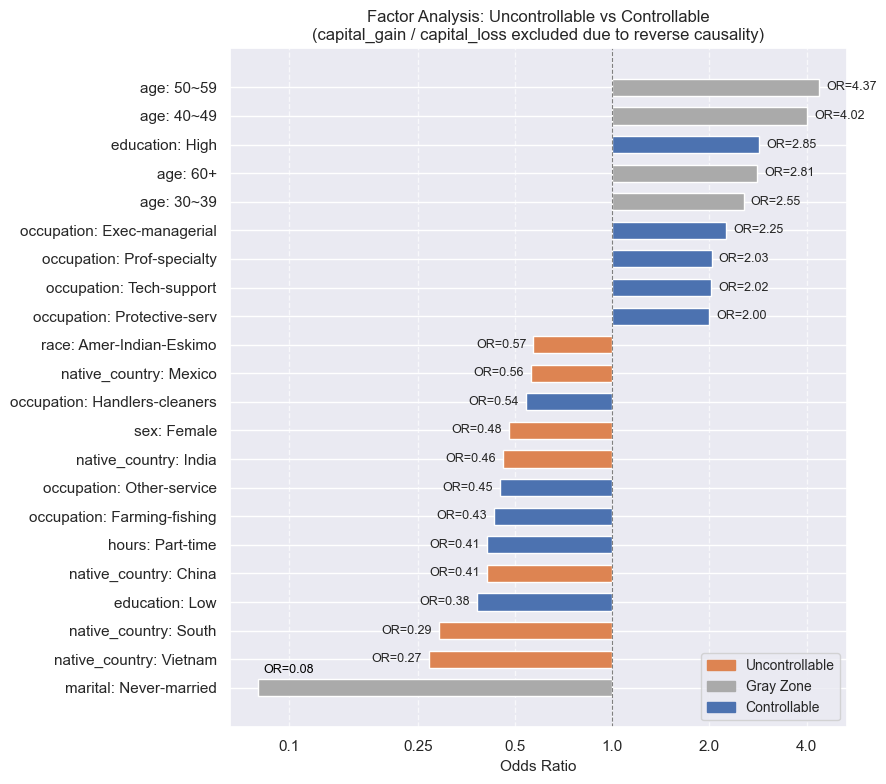

In [38]:
# ============================================================
# 図10： 要因分析
# ============================================================

# -------------------------------------------------------
# 1. データ定義
# -------------------------------------------------------
# 選定基準：p<0.05 かつ OR<0.6 or OR>1.67（対数スケール上で対称なカットオフ）
labels = [
    # コントロール外
    'race: Amer-Indian-Eskimo', 
    'sex: Female', 
    'native_country: China', 
    'native_country: India', 
    'native_country: Mexico', 
    'native_country: South', 
    'native_country: Vietnam',
    # グレーゾーン
    'age: 30~39',
    'age: 40~49',
    'age: 50~59',  
    'age: 60+', 
    'marital: Never-married',
    # コントロール内
    'education: High', 
    'education: Low', 
    'hours: Part-time', 
    'occupation: Exec-managerial',
    'occupation: Farming-fishing', 
    'occupation: Handlers-cleaners', 
    'occupation: Other-service', 
    'occupation: Prof-specialty',
    'occupation: Protective-serv',
    'occupation: Tech-support',
]

effects = [
    # コントロール外
    0.57,   # race: Amer-Indian-Eskimo
    0.48,   # sex: Female
    0.41,   # native_country: China
    0.46,   # native_country: India
    0.56,   # native_country: Mexico
    0.29,   # native_country: South
    0.27,   # native_country: Vietnam
    # グレーゾーン
    2.55,   # age: 30~39
    4.02,   # age: 40~49
    4.37,   # age: 50~59
    2.81,   # age: 60+
    0.08,   # marital: Never-married
    # コントロール内
    2.85,   # education: High
    0.38,   # education: Low
    0.41,   # hours: Part-time
    2.25,   # occupation: Exec-managerial
    0.43,   # occupation: Farming-fishing
    0.54,   # occupation: Handlers-cleaners
    0.45,   # occupation: Other-service
    2.03,   # occupation: Prof-specialty
    2.00,   # occupation: Protective-serv
    2.02,   # occupation: Tech-support
]

categories = [
    'Uncontrollable', 'Uncontrollable', 'Uncontrollable',
    'Uncontrollable', 'Uncontrollable', 'Uncontrollable', 'Uncontrollable', 
    'Gray Zone', 'Gray Zone', 'Gray Zone', 'Gray Zone','Gray Zone',
    'Controllable', 'Controllable', 'Controllable', 'Controllable', 'Controllable',
    'Controllable', 'Controllable', 'Controllable', 'Controllable', 'Controllable', 
]

# -------------------------------------------------------
# 2. 色の設定
# -------------------------------------------------------
color_map = {
    'Uncontrollable': '#DD8452',
    'Gray Zone':      '#AAAAAA',
    'Controllable':   '#4C72B0',
}
colors = [color_map[c] for c in categories]

# -------------------------------------------------------
# 3. log(OR)に変換して並べ替え
# -------------------------------------------------------
# OR値をlog変換することで、OR=0.5とOR=2.0が0から等距離になり
# プラス・マイナスの効果量を対称に比較できる
effects_arr = np.array(effects)
log_effects = np.log(effects_arr)

order = np.argsort(log_effects)
labels_sorted      = [labels[i]       for i in order]
log_effects_sorted = [log_effects[i]  for i in order]
effects_sorted     = [effects[i]      for i in order]
colors_sorted      = [colors[i]       for i in order]

# -------------------------------------------------------
# 4. グラフ描画
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 8))

bars = ax.barh(labels_sorted, log_effects_sorted, color=colors_sorted, height=0.6)

# -------------------------------------------------------
# 5. バーの端にOR値を表示
# -------------------------------------------------------
for bar, or_val in zip(bars, effects_sorted):
    x = bar.get_width()
    if x >= 0:
        # プラス方向：バーの右端の外側に表示
        ax.text(
            x + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f'OR={or_val:.2f}',
            ha='left', va='center', fontsize=9
        )
    elif x > np.log(0.15):
        # マイナス方向（通常）：バーの左端の外側に表示
        ax.text(
            x - 0.05,
            bar.get_y() + bar.get_height() / 2,
            f'OR={or_val:.2f}',
            ha='right', va='center', fontsize=9
        )
    else:
        # マイナス方向（極端に長いバー）：バーの少し上に表示
        ax.text(
            x + 0.4,
            bar.get_y() + bar.get_height() + 0.1,
            f'OR={or_val:.2f}',
            ha='right', va='bottom', fontsize=9, color='black'
        )

# -------------------------------------------------------
# 6. 装飾
# -------------------------------------------------------
# 基準線（log(1.0) = 0）
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')

# x軸の目盛り：対数スケール上の位置にOR値のラベルを表示
# OR=0.25とOR=4.0、OR=0.5とOR=2.0がそれぞれ0から等距離になる
or_ticks = [0.1, 0.25, 0.5, 1.0, 2.0, 4.0]
ax.set_xticks([np.log(v) for v in or_ticks])
ax.set_xticklabels([str(v) for v in or_ticks])

legend_elements = [Patch(color=c, label=k) for k, c in color_map.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.set_xlabel('Odds Ratio', fontsize=11)
ax.set_title(
    'Factor Analysis: Uncontrollable vs Controllable\n'
    '(capital_gain / capital_loss excluded due to reverse causality)',
    fontsize=12
)

ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../images/factor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()